# Bike Sharing Demand Prediction (Regression)

Notebook ini menyajikan proyek end-to-end machine learning regresi untuk memprediksi jumlah penyewaan sepeda (`cnt`) menggunakan data waktu dan cuaca.

### Business Problem Understanding

#### 1. Context
Bike sharing adalah layanan transportasi yang permintaannya berubah-ubah tergantung jam, cuaca, musim, dan hari libur. Jika jumlah sepeda yang disiapkan tidak sesuai kebutuhan, operasional akan tidak efisien: saat demand tinggi terjadi kekurangan unit, saat demand rendah banyak unit menganggur.

#### 2. Problem Statement
Tim operasional membutuhkan cara untuk memperkirakan jumlah penyewaan sepeda (`cnt`) secara lebih akurat berdasarkan kondisi waktu dan cuaca. Tanpa prediksi yang baik, perencanaan distribusi sepeda dan alokasi sumber daya sering tidak tepat.

#### 3. Goals
Project ini bertujuan membangun model machine learning regresi untuk memprediksi nilai `cnt`.

Target project:
- Menghasilkan prediksi jumlah rental sepeda yang cukup akurat pada data baru.
- Membantu operasional menentukan kesiapan unit pada kondisi tertentu (jam, musim, cuaca, hari libur).
- Menyediakan model yang bisa dievaluasi secara terukur dan diinterpretasikan keterbatasannya.

#### 4. Evaluation Metrics
Karena ini kasus regresi, metrik utama yang digunakan adalah:
- MAE (Mean Absolute Error): rata-rata selisih absolut prediksi terhadap aktual, mudah dipahami sebagai rata-rata error jumlah unit.
- RMSE (Root Mean Squared Error): memberi penalti lebih besar untuk error besar, penting untuk menghindari salah prediksi ekstrem pada jam sibuk.
- R-squared: melihat seberapa besar variasi `cnt` yang dapat dijelaskan model.

Fokus bisnis utama: menekan nilai MAE dan RMSE agar kesalahan prediksi jumlah unit semakin kecil.

#### 5. Data Understanding

**Tabel Ringkasan Dataset**

| Komponen | Keterangan |
|---|---|
| Nama dataset | Bike Sharing Dataset |
| Jumlah baris | 12,165 |
| Jumlah kolom | 11 |
| Target | `cnt` (total rental sepeda) |
| Tipe problem | Regresi |

**Tabel Data Dictionary (Kolom dan Makna)**

| Kolom | Deskripsi | Tipe Umum | Peran |
|---|---|---|---|
| `dteday` | Tanggal observasi | Date/Object | Fitur waktu |
| `season` | Musim (1: winter, 2: spring, 3: summer, 4: fall) | Kategorikal (encoded angka) | Fitur |
| `hr` | Jam (0-23) | Numerik diskrit | Fitur waktu |
| `holiday` | Hari libur (0/1) | Biner | Fitur |
| `temp` | Suhu ternormalisasi, rumus: (t - tmin) / (tmax - tmin), tmin=-8, tmax=39 | Numerik kontinu | Fitur cuaca |
| `atemp` | Suhu terasa ternormalisasi, rumus: (t - tmin) / (tmax - tmin), tmin=-16, tmax=50 | Numerik kontinu | Fitur cuaca |
| `hum` | Kelembapan ternormalisasi (dibagi 100) | Numerik kontinu | Fitur cuaca |
| `weathersit` | Kategori cuaca 1-4 (lihat mapping di bawah) | Kategorikal (encoded angka) | Fitur |
| `casual` | Jumlah pengguna kasual | Numerik hitungan | Potensi leakage* |
| `registered` | Jumlah pengguna terdaftar | Numerik hitungan | Potensi leakage* |
| `cnt` | Total rental (`casual + registered`) | Numerik hitungan | **Target** |

**Mapping `weathersit`**
- 1: Clear, Few clouds, Partly cloudy, Partly cloudy
- 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
- 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
- 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog

\*Catatan: karena `cnt = casual + registered`, penggunaan `casual` dan `registered` sebagai prediktor harus disesuaikan dengan skenario bisnis agar tidak terjadi data leakage.

**Catatan Lanjutan Analisis**
- Tahap berikutnya akan mengecek missing values, duplikasi, dan validitas tipe data.
- Fitur final untuk modeling akan dipilih berdasarkan ketersediaan data saat prediksi real-time.

In [10]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gdown
import warnings
warnings.filterwarnings('ignore')

In [11]:
# Load the data
!pip -q install gdown

file_id = "1Qeoeg1HTnwLnF9dsbq2cPVZKZdi3dqpP"
output_file = "data.csv"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file, quiet=False)

df = pd.read_csv(output_file)
print(df.shape)
df.head()

Downloading...
From: https://drive.google.com/uc?id=1Qeoeg1HTnwLnF9dsbq2cPVZKZdi3dqpP
To: /content/data.csv
100%|██████████| 568k/568k [00:00<00:00, 89.3MB/s]

(12165, 11)


,dteday,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt
0,2011-12-09,0.62,1,0,4,0.3485,0.36,16,24,226,250
1,2012-06-17,0.64,1,0,2,0.5152,0.54,4,2,16,18
2,2011-06-15,0.53,1,0,2,0.6212,0.62,23,17,90,107
3,2012-03-31,0.87,2,0,2,0.3485,0.36,8,19,126,145
4,2012-07-31,0.55,1,0,3,0.6970,0.76,18,99,758,857


### Data Understanding

Pada tahap ini dilakukan validasi struktur data sebelum modeling regresi, meliputi:
- Pemeriksaan bentuk data, tipe data, dan statistik deskriptif.
- Pemeriksaan missing value dan duplikasi.
- Penyusunan tabel profil kolom untuk dokumentasi kualitas data.

In [12]:
# Additional imports for regression workflow
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import pickle

In [15]:
# Structured data checks and profiling table
print('Shape:', df.shape)

summary_table = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'missing_count': df.isna().sum().values,
    'missing_pct': (df.isna().mean() * 100).round(2).values,
    'n_unique': df.nunique(dropna=False).values,
    'sample_value': [df[col].dropna().iloc[0] if df[col].notna().any() else np.nan for col in df.columns]
})

display(summary_table)

print('Duplicate rows:', df.duplicated().sum())
print('\nPreview data:')
display(df.head())

print('\nDescriptive statistics (numeric):')
display(df.describe().T)

Shape: (12165, 11)


,column,dtype,missing_count,missing_pct,n_unique,sample_value
0,dteday,object,0,0.0,731,2011-12-09
1,hum,float64,0,0.0,89,0.62
2,weathersit,int64,0,0.0,4,1
3,holiday,int64,0,0.0,2,0
4,season,int64,0,0.0,4,4
5,atemp,float64,0,0.0,65,0.3485
6,temp,float64,0,0.0,50,0.36
7,hr,int64,0,0.0,24,16
8,casual,int64,0,0.0,305,24
9,registered,int64,0,0.0,742,226


Duplicate rows: 0

Preview data:


,dteday,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt
0,2011-12-09,0.62,1,0,4,0.3485,0.36,16,24,226,250
1,2012-06-17,0.64,1,0,2,0.5152,0.54,4,2,16,18
2,2011-06-15,0.53,1,0,2,0.6212,0.62,23,17,90,107
3,2012-03-31,0.87,2,0,2,0.3485,0.36,8,19,126,145
4,2012-07-31,0.55,1,0,3,0.6970,0.76,18,99,758,857



Descriptive statistics (numeric):


,count,mean,std,min,25%,50%,75%,max
hum,12165.0,0.625451,0.192102,0.00,0.4700,0.6200,0.7800,1.0
weathersit,12165.0,1.416934,0.635937,1.00,1.0000,1.0000,2.0000,4.0
holiday,12165.0,0.029758,0.169925,0.00,0.0000,0.0000,0.0000,1.0
season,12165.0,2.488615,1.106157,1.00,2.0000,2.0000,3.0000,4.0
atemp,12165.0,0.476996,0.171857,0.00,0.3333,0.4848,0.6212,1.0
temp,12165.0,0.498185,0.192492,0.02,0.3400,0.5000,0.6600,1.0
hr,12165.0,11.519770,6.931872,0.00,6.0000,12.0000,18.0000,23.0
casual,12165.0,35.834443,49.489286,0.00,4.0000,17.0000,49.0000,362.0
registered,12165.0,153.436580,151.046123,0.00,34.0000,115.0000,220.0000,876.0
cnt,12165.0,189.271023,181.223903,1.00,40.0000,142.0000,282.0000,970.0


### Exploratory Data Analysis (EDA)

Bagian ini bertujuan memahami pola utama pada data sebelum modeling regresi.

Fokus EDA:
- Distribusi target `cnt`.
- Korelasi antar fitur numerik terhadap target.
- Pola rata-rata demand berdasarkan jam (`hr`), musim (`season`), dan kondisi cuaca (`weathersit`).

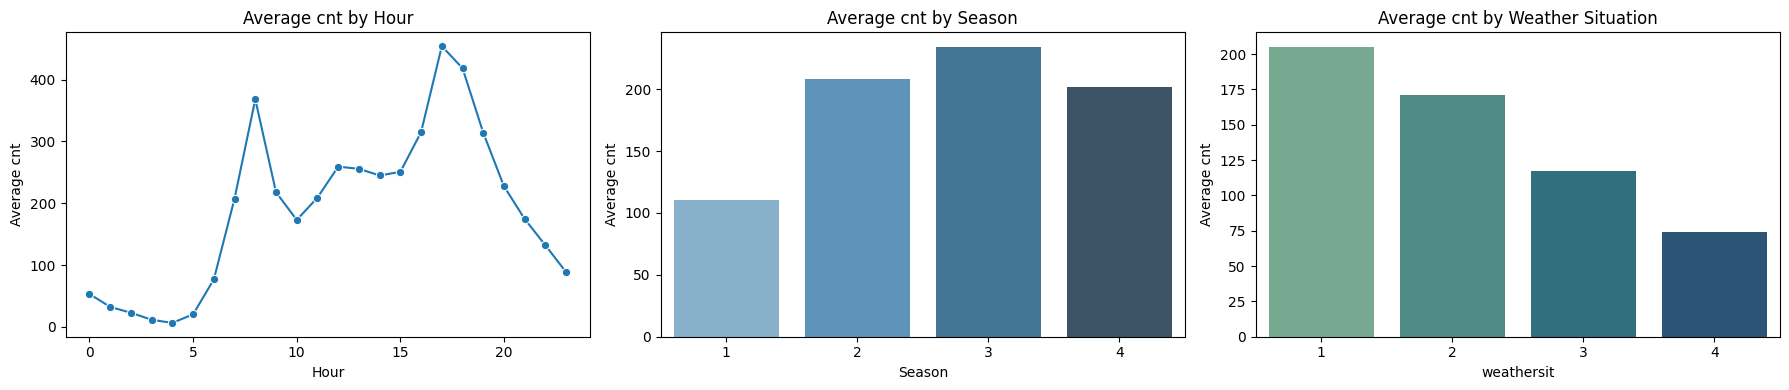

In [18]:
# EDA 3: Average demand patterns by hour, season, and weather
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

hourly_pattern = df.groupby('hr', as_index=False)['cnt'].mean()
sns.lineplot(data=hourly_pattern, x='hr', y='cnt', marker='o', ax=axes[0])
axes[0].set_title('Average cnt by Hour')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Average cnt')

season_pattern = df.groupby('season', as_index=False)['cnt'].mean()
sns.barplot(data=season_pattern, x='season', y='cnt', palette='Blues_d', ax=axes[1])
axes[1].set_title('Average cnt by Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Average cnt')

weather_pattern = df.groupby('weathersit', as_index=False)['cnt'].mean()
sns.barplot(data=weather_pattern, x='weathersit', y='cnt', palette='crest', ax=axes[2])
axes[2].set_title('Average cnt by Weather Situation')
axes[2].set_xlabel('weathersit')
axes[2].set_ylabel('Average cnt')

plt.tight_layout()
plt.show()

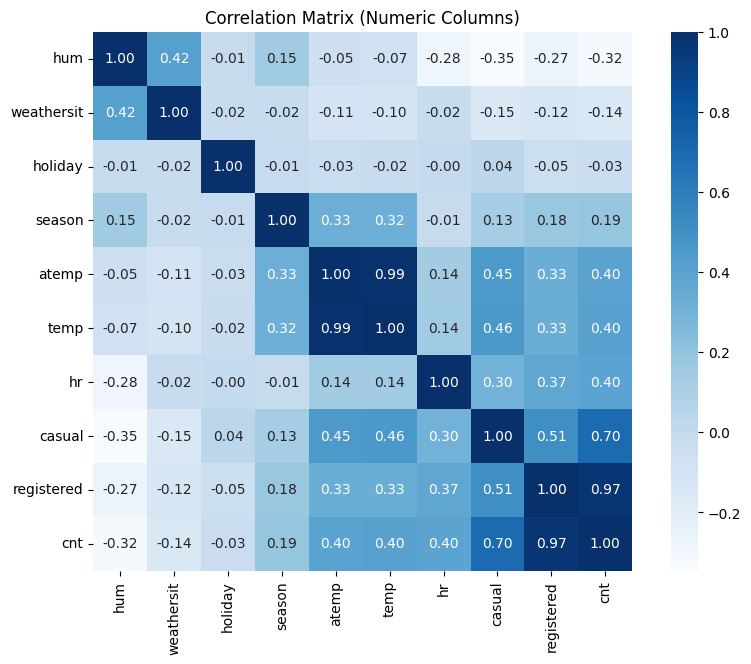

In [19]:
# EDA 2: Correlation heatmap (numeric features)
num_cols = df.select_dtypes(include=['number']).columns.tolist()

plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='Blues', square=True)
plt.title('Correlation Matrix (Numeric Columns)')
plt.show()

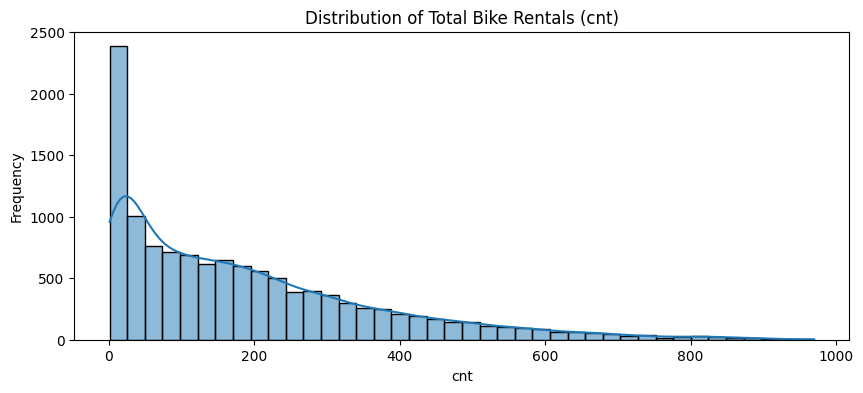

In [20]:
# EDA 1: Target distribution
plt.figure(figsize=(10, 4))
sns.histplot(df['cnt'], bins=40, kde=True)
plt.title('Distribution of Total Bike Rentals (cnt)')
plt.xlabel('cnt')
plt.ylabel('Frequency')
plt.show()

### Data Preprocessing
Tahap ini menyiapkan fitur untuk model regresi, termasuk konversi tanggal dan pemisahan train-test.

In [16]:
# Feature engineering and train-test split
# Exclude columns that can cause target leakage: cnt = casual + registered
data = df.copy()

data['dteday'] = pd.to_datetime(data['dteday'])
data['year'] = data['dteday'].dt.year
data['month'] = data['dteday'].dt.month
data['dayofweek'] = data['dteday'].dt.dayofweek

target_col = 'cnt'
leakage_cols = ['casual', 'registered']
feature_cols = [c for c in data.columns if c not in [target_col, 'dteday'] + leakage_cols]

X = data[feature_cols]
y = data[target_col]

categorical_features = ['season', 'weathersit', 'holiday', 'hr', 'year', 'month', 'dayofweek']
categorical_features = [c for c in categorical_features if c in X.columns]
numeric_features = [c for c in X.columns if c not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)
print('Excluded leakage columns:', leakage_cols)
print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

Train shape: (9732, 10)
Test shape : (2433, 10)
Excluded leakage columns: ['casual', 'registered']
Numeric features: ['hum', 'atemp', 'temp']
Categorical features: ['season', 'weathersit', 'holiday', 'hr', 'year', 'month', 'dayofweek']


### Modeling (Regression)
Model yang dibandingkan:
- Linear Regression (baseline)
- Random Forest Regressor
- Gradient Boosting Regressor

In [ ]:
# Train and compare multiple regression models
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(random_state=42, n_estimators=250, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
rows = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

    cv_scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error',
            'r2': 'r2'
        },
        n_jobs=-1
    )

    pipe.fit(X_train, y_train)
    y_pred_test = pipe.predict(X_test)

    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_r2 = r2_score(y_test, y_pred_test)

    rows.append({
        'model': name,
        'cv_mae': -cv_scores['test_mae'].mean(),
        'cv_rmse': -cv_scores['test_rmse'].mean(),
        'cv_r2': cv_scores['test_r2'].mean(),
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_r2': test_r2
    })

    fitted_pipelines[name] = pipe

results = pd.DataFrame(rows).sort_values(by='test_rmse').reset_index(drop=True)
display(results)

In [ ]:
# Select final model based on the lowest test RMSE
best_model_name = results.loc[0, 'model']
final_model = fitted_pipelines[best_model_name]

final_pred = final_model.predict(X_test)
final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
final_r2 = r2_score(y_test, final_pred)

print(f'Final model: {best_model_name}')
print(f'MAE  : {final_mae:.4f}')
print(f'RMSE : {final_rmse:.4f}')
print(f'R2   : {final_r2:.4f}')

NameError: name 'final_pred' is not defined

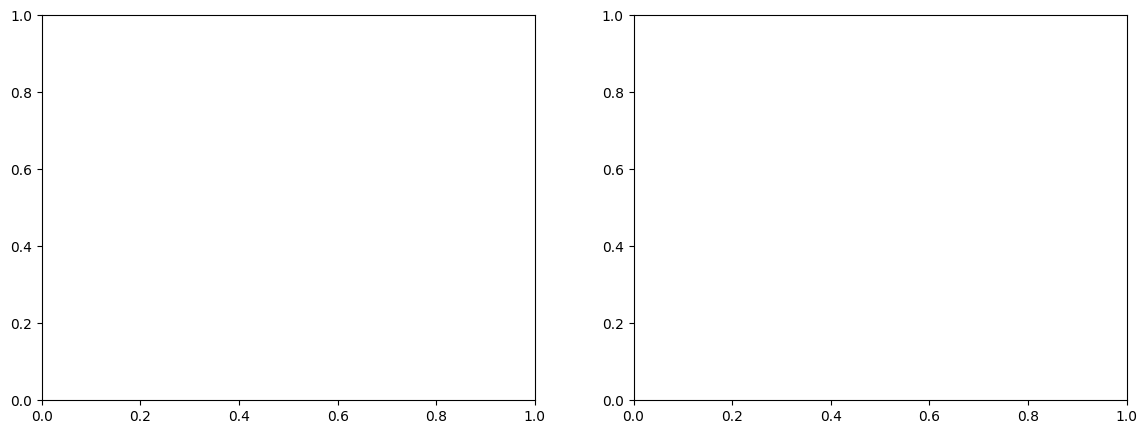

In [17]:
# Simple diagnostics: actual vs predicted and residual distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_test, y=final_pred, alpha=0.4, ax=axes[0])
axes[0].set_title('Actual vs Predicted')
axes[0].set_xlabel('Actual cnt')
axes[0].set_ylabel('Predicted cnt')

residuals = y_test - final_pred
sns.histplot(residuals, bins=40, kde=True, ax=axes[1])
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.show()

### Conclusion
Kesimpulan diisi setelah seluruh cell dijalankan:
- Model final dipilih berdasarkan nilai RMSE test paling rendah.
- MAE digunakan untuk membaca rata-rata selisih prediksi terhadap nilai aktual.
- RMSE digunakan untuk memberi penalti lebih besar pada error besar.
- R-squared menunjukkan seberapa besar variasi `cnt` yang bisa dijelaskan model.

Template narasi:
- Model terbaik: **[isi otomatis dari output]**.
- Dengan MAE = **[nilai]** dan RMSE = **[nilai]**, model sudah/cukup baik untuk estimasi demand harian per observasi.
- Namun model tetap memiliki limitasi saat kondisi ekstrem/cuaca/event tertentu yang tidak tertangkap data.

### Recommendations
- Gunakan model untuk membantu perencanaan operasional (alokasi unit sepeda dan staffing) pada jam dengan demand tinggi.
- Lakukan retraining berkala agar model tetap relevan terhadap pola demand terbaru.
- Tambahkan fitur eksternal (misalnya event kota, kondisi cuaca detail, lokasi stasiun) untuk peningkatan performa.
- Terapkan monitoring performa model (drift data dan drift error) setelah implementasi.

### Save Model

In [ ]:
# Save final regression model and metadata
artifact = {
    'model_name': best_model_name,
    'pipeline': final_model,
    'feature_columns': feature_cols,
    'target_column': target_col,
    'metrics': {
        'mae': float(final_mae),
        'rmse': float(final_rmse),
        'r2': float(final_r2)
    }
}

with open('best_bike_sharing_regression_model.pkl', 'wb') as f:
    pickle.dump(artifact, f)

print('Model saved to best_bike_sharing_regression_model.pkl')